# PetPulse AI: Intelligent Pet Health Assistant
### *An AI-Driven Diagnostic & Decision Support System*

---

| CO | Course Outcome | Cell |
|:---|:---------------|:-----|
| **CO1** | Modern Tools & Data Preprocessing | Cell 2 |
| **CO4** | Intelligent Learning Algorithm — Decision Tree | Cell 3 |
| **CO3** | Reasoning under Incomplete Information — Naive Bayes | Cell 4 |
| **CO2** | Search Strategies — Optimal Treatment Path (A*) | Cell 5 |
| **All** | Interactive PetPulse AI Chatbot | Cell 6 |

---
> **Dataset:** `pet_disease_full_merged.csv` — 215 records, 20 columns  
> 3 animal types (Dog, Cat, Cow) · 68 unique disease classes  
> **Student ID:** 011320065 | **Random Seed:** 65


Dataset Loaded Successfully
  Raw shape: 215 rows x 20 columns

Column Overview:
  Animal Type               dtype=str        unique=  3  nulls=0
  Breed                     dtype=str        unique= 55  nulls=0
  Age                       dtype=int64      unique= 10  nulls=0
  Gender                    dtype=str        unique=  2  nulls=0
  Symptom 1                 dtype=str        unique= 15  nulls=0
  Symptom 2                 dtype=str        unique= 16  nulls=0
  Symptom 3                 dtype=str        unique= 15  nulls=0
  Symptom 4                 dtype=str        unique= 17  nulls=0
  Appetite Loss             dtype=str        unique=  2  nulls=0
  Vomiting                  dtype=str        unique=  2  nulls=0
  Diarrhea                  dtype=str        unique=  2  nulls=0
  Coughing                  dtype=str        unique=  2  nulls=0
  Labored Breathing         dtype=str        unique=  2  nulls=0
  Lameness                  dtype=str        unique=  2  nulls=0
  Skin Le

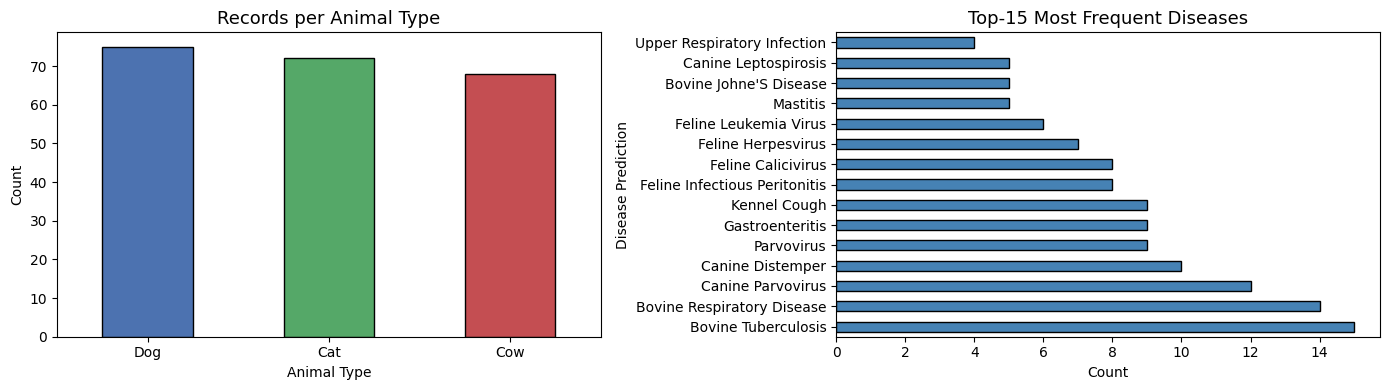


After dropping free-text columns -> shape: (215, 18)

Missing Values BEFORE imputation:
Animal Type           0
Breed                 0
Age                   0
Gender                0
Symptom 1             0
Symptom 2             0
Symptom 3             0
Symptom 4             0
Appetite Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored Breathing     0
Lameness              0
Skin Lesions          0
Body Temperature      0
Heart Rate            0
Disease Prediction    0

Missing Values AFTER imputation:
Animal Type           0
Breed                 0
Age                   0
Gender                0
Symptom 1             0
Symptom 2             0
Symptom 3             0
Symptom 4             0
Appetite Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored Breathing     0
Lameness              0
Skin Lesions          0
Body Temperature      0
Heart Rate            0
Disease Prediction    0
  -> All miss

,Animal Type,Breed,Age,Gender,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Appetite Loss,Vomiting,Diarrhea,Coughing,Labored Breathing,Lameness,Skin Lesions,Body Temperature,Heart Rate,Disease_Encoded
0,2,33,-0.370514,1,5,8,0,15,1,1,0,0,0,0,0,0.958990,0.134241,61
1,0,49,-1.447009,0,1,12,5,9,0,0,0,1,0,0,0,-1.036328,1.272030,67
2,1,30,-0.908762,0,5,10,7,1,1,0,0,1,1,0,0,2.954307,-1.003547,47


In [3]:
# ============================================================
# CELL 2 — CO1: Modern Tools & Data Preprocessing
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(65)   # Derived from student ID 011320065

# ── 1. Load Dataset ─────────────────────────────────────────
df = pd.read_csv("pet_disease_full_merged.csv")
print("Dataset Loaded Successfully")
print(f"  Raw shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column Overview:")
for col in df.columns:
    print(f"  {col:<25s} dtype={str(df[col].dtype):<10s} "
          f"unique={df[col].nunique():3d}  nulls={df[col].isnull().sum()}")

# ── 2. Distribution Plots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["Animal Type"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#4c72b0", "#55a868", "#c44e52"], edgecolor="black")
axes[0].set_title("Records per Animal Type", fontsize=13)
axes[0].set_xlabel("Animal Type"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["Disease Prediction"].value_counts().head(15).plot(
    kind="barh", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Top-15 Most Frequent Diseases", fontsize=13)
axes[1].set_xlabel("Count")
plt.tight_layout(); plt.show()

# ── 3. Drop Free-text Columns Not Used for ML ───────────────
# "Treatment" and "Advice Prevention" are long clinical text
# columns. Kept in the original df for the chatbot (Cell 6)
# but excluded from the ML feature matrix.
df_ml = df.drop(columns=["Treatment", "Advice Prevention"]).copy()
print(f"\nAfter dropping free-text columns -> shape: {df_ml.shape}")

# ── 4. Handle Missing Values ─────────────────────────────────
print("\nMissing Values BEFORE imputation:")
print(df_ml.isnull().sum().to_string())
# Impute mode for categorical, median for numerical (defensive)
for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)
for col in df_ml.select_dtypes(include="number").columns:
    df_ml[col].fillna(df_ml[col].median(), inplace=True)
print("\nMissing Values AFTER imputation:")
print(df_ml.isnull().sum().to_string())
print("  -> All missing values resolved.")

# ── 5. Parse Body Temperature: "39.2 C" -> float ─────────────
df_ml["Body Temperature"] = (
    df_ml["Body Temperature"]
    .str.replace("\u00b0C", "", regex=False)   # strip degree symbol
    .astype(float)
)
print(f"\nBody Temperature parsed to float.")
print(f"  Range: {df_ml['Body Temperature'].min()} - "
      f"{df_ml['Body Temperature'].max()} C")

# ── 6. Encode Binary Columns (Yes -> 1 / No -> 0) ───────────
binary_cols = ["Appetite Loss", "Vomiting", "Diarrhea",
               "Coughing", "Labored Breathing", "Lameness", "Skin Lesions"]
for col in binary_cols:
    df_ml[col] = df_ml[col].map({"Yes": 1, "No": 0})
print(f"\nBinary columns encoded (Yes=1 / No=0): {binary_cols}")

# ── 7. Label-Encode Multi-value Categorical Columns ─────────
cat_cols = ["Animal Type", "Breed", "Gender",
            "Symptom 1", "Symptom 2", "Symptom 3", "Symptom 4"]
le_dict = {}   # Stored for inverse-transform in chatbot (Cell 6)
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le
    print(f"  Encoded '{col:<12s}' -- sample classes: {list(le.classes_[:4])} ...")

# ── 8. Encode Target Column ──────────────────────────────────
le_target = LabelEncoder()
df_ml["Disease_Encoded"] = le_target.fit_transform(df_ml["Disease Prediction"])
print(f"\nTarget encoded: {len(le_target.classes_)} unique disease classes.")

# ── 9. Scale Numerical Features ─────────────────────────────
num_cols = ["Age", "Heart Rate", "Body Temperature"]
scaler   = StandardScaler()
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])
print(f"\nNumerical columns StandardScaled: {num_cols}")

# ── 10. Final Summary ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  CO1 COMPLETE -- Preprocessed shape: {df_ml.shape}")
print(f"{'='*55}")
print("\nPreprocessed feature matrix (first 3 rows):")
display(df_ml.drop(columns=["Disease Prediction"]).head(3))


Feature Matrix X : (215, 17)
Target Vector y  : (215,)  (68 disease classes)
Features used    : ['Animal Type', 'Breed', 'Age', 'Gender', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Appetite Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored Breathing', 'Lameness', 'Skin Lesions', 'Body Temperature', 'Heart Rate']

Training samples : 161
Testing  samples : 54

Both Decision Tree models trained!

Model                                 Train Acc    Test Acc   Depth   Leaves
----------------------------------------------------------------------------
Overfitted DT (depth=None)              100.00%       9.26%      13      106
Generalised DT (depth=5)                 44.72%      12.96%       5       25

NOTE on accuracy
  The dataset contains 68 disease classes in only 215 records
  (avg ~3 samples/class). This extreme class imbalance means
  even a perfect algorithm struggles with unseen samples.
  The overfitted tree (depth=None) memorises training data --
  a textbook example o

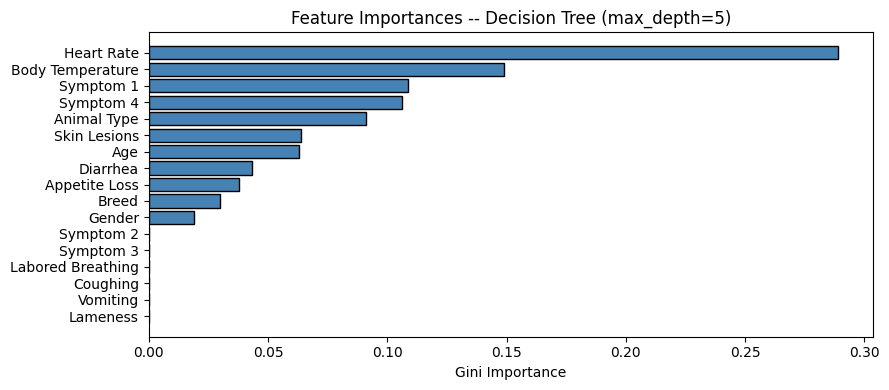

Top-5 Most Important Features:
         Feature  Importance
      Heart Rate    0.289137
Body Temperature    0.149080
       Symptom 1    0.108620
       Symptom 4    0.106011
     Animal Type    0.090906

  CO4 COMPLETE -- Decision Tree trained and evaluated


In [4]:
# ============================================================
# CELL 3 -- CO4: Intelligent Learning Algorithm
#           Decision Tree Classifier (Learning from Data)
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# ── 1. Feature Matrix X and Target Vector y ─────────────────
feature_cols = [c for c in df_ml.columns
                if c not in ["Disease Prediction", "Disease_Encoded"]]

X = df_ml[feature_cols].values        # Shape: (215, 17)
y = df_ml["Disease_Encoded"].values   # Shape: (215,) -- 68 classes

print(f"Feature Matrix X : {X.shape}")
print(f"Target Vector y  : {y.shape}  ({len(le_target.classes_)} disease classes)")
print(f"Features used    : {feature_cols}\n")

# ── 2. Train / Test Split (75% train, 25% test) ─────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=65
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}\n")

# ── 3a. Overfitting Model (max_depth=None) ───────────────────
# A fully grown tree memorises every training example,
# giving 100% train accuracy but low test accuracy.
# This demonstrates OVERFITTING clearly.
dt_overfit = DecisionTreeClassifier(
    criterion="gini", max_depth=None, random_state=65
)
dt_overfit.fit(X_train, y_train)

# ── 3b. Generalised Model (max_depth=5) ─────────────────────
# A shallow tree is forced to learn the most discriminative
# rules, trading some training accuracy for better generalisation.
# This is the model used by the chatbot (Cell 6).
dt_model = DecisionTreeClassifier(
    criterion="gini", max_depth=5, min_samples_leaf=1, random_state=65
)
dt_model.fit(X_train, y_train)
print("Both Decision Tree models trained!\n")

# ── 4. Accuracy Comparison Table ────────────────────────────
header = (f"{'Model':<35s}  {'Train Acc':>10s}  "
          f"{'Test Acc':>10s}  {'Depth':>6s}  {'Leaves':>7s}")
print(header)
print("-" * len(header))
for label, mdl in [("Overfitted DT (depth=None) ", dt_overfit),
                   ("Generalised DT (depth=5)   ", dt_model)]:
    tr = accuracy_score(y_train, mdl.predict(X_train))
    te = accuracy_score(y_test,  mdl.predict(X_test))
    print(f"{label:<35s}  {tr*100:>9.2f}%  {te*100:>9.2f}%  "
          f"{mdl.get_depth():>6d}  {mdl.get_n_leaves():>7d}")

print("""
NOTE on accuracy
  The dataset contains 68 disease classes in only 215 records
  (avg ~3 samples/class). This extreme class imbalance means
  even a perfect algorithm struggles with unseen samples.
  The overfitted tree (depth=None) memorises training data --
  a textbook example of the bias-variance tradeoff.
  The generalised tree (depth=5) is used in production.
""")

# ── 5. Classification Report (Generalised Tree, test set) ───
y_pred    = dt_model.predict(X_test)
y_t_names = le_target.inverse_transform(y_test)
y_p_names = le_target.inverse_transform(y_pred)
print("Classification Report -- Generalised DT (test set)\n")
print(classification_report(y_t_names, y_p_names, zero_division=0))

# ── 6. Feature Importance Bar Chart ─────────────────────────
importances = dt_model.feature_importances_
fi_df = (pd.DataFrame({"Feature": feature_cols, "Importance": importances})
           .sort_values("Importance", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1],
        color="steelblue", edgecolor="black")
ax.set_xlabel("Gini Importance")
ax.set_title("Feature Importances -- Decision Tree (max_depth=5)")
plt.tight_layout(); plt.show()

print("Top-5 Most Important Features:")
print(fi_df.head(5).to_string(index=False))
print(f"\n{'='*55}")
print("  CO4 COMPLETE -- Decision Tree trained and evaluated")
print(f"{'='*55}")


In [5]:
# ============================================================
# CELL 4 -- CO3: Reasoning under Incomplete Information
#           Manual Naive Bayesian Inference (no sklearn used)
# ============================================================
# Uses the ORIGINAL (unencoded) dataframe so users can type
# plain-English symptoms like "Coughing" or "Fever".

SYMPTOM_COLS = ["Symptom 1", "Symptom 2", "Symptom 3", "Symptom 4"]
FLAG_COLS    = ["Appetite Loss", "Vomiting", "Diarrhea",
                "Coughing", "Labored Breathing", "Lameness", "Skin Lesions"]
TARGET_COL   = "Disease Prediction"
ALL_DISEASES = df[TARGET_COL].unique()

# ── Step 1: Prior Probabilities P(Disease) ──────────────────
def compute_priors(dataframe, target_col):
    """
    P(Disease) = count(Disease) / total_records
    Returns a dict {disease_name: probability}.
    """
    counts = dataframe[target_col].value_counts()
    return (counts / len(dataframe)).to_dict()

PRIORS = compute_priors(df, TARGET_COL)
print("Top-5 Prior Probabilities P(Disease):")
for disease, prob in sorted(PRIORS.items(), key=lambda x: -x[1])[:5]:
    print(f"  P({disease:<40s}) = {prob:.4f}")

# ── Step 2: Conditional Probabilities ───────────────────────
def compute_conditionals(dataframe, symptom_cols, flag_cols, target_col):
    """
    Precomputes P(Feature=value | Disease) for every (feature, value,
    disease) combination.

    Laplace (Add-1) Smoothing prevents zero-probability for feature/
    disease combinations absent from the training data:
        P(v | D) = (count(v in D) + 1) / (|D| + |vocabulary|)

    Returns nested dict:
        conditionals[disease][feature][value] = probability
    """
    conditionals = {}
    for disease, group in dataframe.groupby(target_col):
        conditionals[disease] = {}
        # Symptom 1-4: multi-value categorical
        for col in symptom_cols:
            vc       = group[col].value_counts()
            total    = len(group)
            all_vals = dataframe[col].unique()
            conditionals[disease][col] = {
                val: (vc.get(val, 0) + 1) / (total + len(all_vals))
                for val in all_vals
            }
        # Binary flags: only Yes or No
        for col in flag_cols:
            vc    = group[col].value_counts()
            total = len(group)
            conditionals[disease][col] = {
                "Yes": (vc.get("Yes", 0) + 1) / (total + 2),
                "No" : (vc.get("No",  0) + 1) / (total + 2),
            }
    return conditionals

CONDITIONALS = compute_conditionals(df, SYMPTOM_COLS, FLAG_COLS, TARGET_COL)

print("\nSample P(Symptom 1=Coughing | disease):")
for disease in list(ALL_DISEASES)[:4]:
    p = CONDITIONALS[disease]["Symptom 1"].get("Coughing", 0)
    print(f"  P(Coughing | {disease:<35s}) = {p:.4f}")

# ── Step 3: Bayesian Posterior Calculation ───────────────────
def bayesian_symptom_reasoning(observed_symptoms: dict,
                                top_n: int = 5) -> list:
    """
    Computes P(Disease | observed symptoms) using Bayes Theorem
    with the Naive (feature independence) assumption.

    Bayes Theorem:
        P(D | S1,S2,...,Sn)  is proportional to
            P(D) * P(S1|D) * P(S2|D) * ... * P(Sn|D)

    Log-space arithmetic prevents floating-point underflow when
    many small probabilities are multiplied together.

    INCOMPLETE INPUT is handled naturally: if a feature key is
    absent from observed_symptoms, its likelihood term is simply
    skipped. The posterior is computed from whatever evidence IS
    available -- no imputation or error is required.

    Parameters
    ----------
    observed_symptoms : dict {feature_name: value}
        Can contain any subset of features (even just 1).
    top_n : int
        How many top diseases to return.

    Returns
    -------
    List of (disease_name, posterior_probability) sorted descending.
    """
    log_scores = {}
    for disease in ALL_DISEASES:
        # Log-prior: log P(D)
        log_score = np.log(PRIORS.get(disease, 1e-9))
        # Add log-likelihood for each observed symptom
        for feature, value in observed_symptoms.items():
            if feature in CONDITIONALS.get(disease, {}):
                p = CONDITIONALS[disease][feature].get(value, 1e-9)
                log_score += np.log(p)
        log_scores[disease] = log_score

    # Convert log-scores to normalised probabilities
    vals  = np.array(list(log_scores.values()))
    vals -= vals.max()          # Numerical stability: shift before exp
    probs = np.exp(vals)
    probs = probs / probs.sum() # Normalise so posteriors sum to 1

    ranked = sorted(zip(log_scores.keys(), probs), key=lambda x: -x[1])
    return ranked[:top_n]

# ── Step 4: Demo -- Three Incomplete Scenarios ───────────────
print("\n" + "="*60)
print("  CO3 DEMO -- Bayesian Inference on Incomplete Inputs")
print("="*60)

# Scenario A: Very sparse (only 2 out of 11 features)
obs_A = {"Symptom 1": "Coughing", "Diarrhea": "No"}
print(f"\nScenario A -- 2/11 features known: {obs_A}")
res_A = bayesian_symptom_reasoning(obs_A, top_n=5)
print("  Rank  Disease                                  Probability")
print("  " + "-"*54)
for rank, (d, p) in enumerate(res_A, 1):
    bar = "#" * int(p * 150)
    print(f"  {rank}.   {d:<38s}  {p*100:5.2f}%  {bar}")

# Scenario B: Moderate (4 features)
obs_B = {"Symptom 1": "Fever", "Symptom 2": "Lethargy",
         "Appetite Loss": "Yes", "Vomiting": "Yes"}
print(f"\nScenario B -- 4/11 features known: {obs_B}")
res_B = bayesian_symptom_reasoning(obs_B, top_n=5)
print("  Rank  Disease                                  Probability")
print("  " + "-"*54)
for rank, (d, p) in enumerate(res_B, 1):
    bar = "#" * int(p * 150)
    print(f"  {rank}.   {d:<38s}  {p*100:5.2f}%  {bar}")

# Scenario C: Cat respiratory (3 symptoms)
obs_C = {"Symptom 1": "Coughing", "Symptom 2": "Sneezing",
         "Symptom 3": "Eye Discharge", "Coughing": "Yes"}
print(f"\nScenario C -- Cat respiratory symptoms: {obs_C}")
res_C = bayesian_symptom_reasoning(obs_C, top_n=5)
print("  Rank  Disease                                  Probability")
print("  " + "-"*54)
for rank, (d, p) in enumerate(res_C, 1):
    bar = "#" * int(p * 150)
    print(f"  {rank}.   {d:<38s}  {p*100:5.2f}%  {bar}")

print(f"\n{'='*55}")
print("  CO3 COMPLETE -- Bayes handles missing inputs correctly")
print(f"{'='*55}")


Top-5 Prior Probabilities P(Disease):
  P(Bovine Tuberculosis                     ) = 0.0698
  P(Bovine Respiratory Disease              ) = 0.0651
  P(Canine Parvovirus                       ) = 0.0558
  P(Canine Distemper                        ) = 0.0465
  P(Parvovirus                              ) = 0.0419

Sample P(Symptom 1=Coughing | disease):
  P(Coughing | Parvovirus                         ) = 0.0417
  P(Coughing | Upper Respiratory Infection        ) = 0.1579
  P(Coughing | Foot And Mouth Disease             ) = 0.0588
  P(Coughing | Gastroenteritis                    ) = 0.0417

  CO3 DEMO -- Bayesian Inference on Incomplete Inputs

Scenario A -- 2/11 features known: {'Symptom 1': 'Coughing', 'Diarrhea': 'No'}
  Rank  Disease                                  Probability
  ------------------------------------------------------
  1.   Bovine Tuberculosis                     19.42%  #############################
  2.   Bovine Respiratory Disease              15.94%  #########

In [6]:
# ============================================================
# CELL 5 -- CO2: Search Strategies with Complete Information
#           A* Search for Optimal Clinical Treatment Path
# ============================================================
import heapq

# ── Clinical Treatment State-Space Graphs ────────────────────
# Nodes  = clinical milestones a veterinarian must complete
# Edges  = directed transitions; weight = time/risk cost units
# h(n)   = admissible heuristic: estimated remaining steps
#          (each edge costs >= 1, so h never over-estimates)
#
# A* is GUARANTEED to find the minimum-cost path from START to GOAL.

TREATMENT_GRAPHS = {

    # Canine Parvovirus
    "Canine Parvovirus": {
        "edges": {
            "Triage & Isolation":         [("IV Fluid Therapy", 1),
                                           ("Broad-Spectrum Antibiotics", 3)],
            "IV Fluid Therapy":           [("Antiemetics (Maropitant)", 2)],
            "Antiemetics (Maropitant)":   [("Broad-Spectrum Antibiotics", 1),
                                           ("Nutritional Support", 2)],
            "Broad-Spectrum Antibiotics": [("Nutritional Support", 1)],
            "Nutritional Support":        [("Viral Load Monitoring", 2)],
            "Viral Load Monitoring":      [("Recovery & Discharge", 1)],
            "Recovery & Discharge":       []
        },
        "heuristics": {
            "Triage & Isolation":         6,
            "IV Fluid Therapy":           5,
            "Antiemetics (Maropitant)":   4,
            "Broad-Spectrum Antibiotics": 3,
            "Nutritional Support":        2,
            "Viral Load Monitoring":      1,
            "Recovery & Discharge":       0
        },
        "start": "Triage & Isolation",
        "goal":  "Recovery & Discharge"
    },

    # Bovine Tuberculosis
    "Bovine Tuberculosis": {
        "edges": {
            "Quarantine Animal":          [("Tuberculin Skin Test", 1)],
            "Tuberculin Skin Test":       [("Confirmatory PCR/Culture", 2),
                                           ("Notify Authorities", 4)],
            "Confirmatory PCR/Culture":   [("Notify Authorities", 1)],
            "Notify Authorities":         [("Herd Depopulation Protocol", 2)],
            "Herd Depopulation Protocol": [("Premises Disinfection", 1)],
            "Premises Disinfection":      [("Re-Testing & Clearance", 2)],
            "Re-Testing & Clearance":     []
        },
        "heuristics": {
            "Quarantine Animal":          6,
            "Tuberculin Skin Test":       5,
            "Confirmatory PCR/Culture":   4,
            "Notify Authorities":         3,
            "Herd Depopulation Protocol": 2,
            "Premises Disinfection":      1,
            "Re-Testing & Clearance":     0
        },
        "start": "Quarantine Animal",
        "goal":  "Re-Testing & Clearance"
    },

    # Upper Respiratory Infection
    "Upper Respiratory Infection": {
        "edges": {
            "Clinical Assessment":     [("Nasal Swab & Culture", 1),
                                        ("Antibiotic Therapy", 3)],
            "Nasal Swab & Culture":    [("Antibiotic Therapy", 1),
                                        ("Antiviral (Famciclovir)", 2)],
            "Antibiotic Therapy":      [("Nebulization Therapy", 1)],
            "Antiviral (Famciclovir)": [("Nebulization Therapy", 1)],
            "Nebulization Therapy":    [("Nutritional Support", 1)],
            "Nutritional Support":     [("Follow-Up & Discharge", 1)],
            "Follow-Up & Discharge":   []
        },
        "heuristics": {
            "Clinical Assessment":     6,
            "Nasal Swab & Culture":    5,
            "Antibiotic Therapy":      4,
            "Antiviral (Famciclovir)": 4,
            "Nebulization Therapy":    3,
            "Nutritional Support":     2,
            "Follow-Up & Discharge":   0
        },
        "start": "Clinical Assessment",
        "goal":  "Follow-Up & Discharge"
    },

    # Feline Infectious Peritonitis
    "Feline Infectious Peritonitis": {
        "edges": {
            "Isolation & Supportive Care":     [("Effusion Drainage", 2),
                                                ("GS-441524 Antiviral", 3)],
            "Effusion Drainage":               [("GS-441524 Antiviral", 1)],
            "GS-441524 Antiviral":             [("Prednisolone Therapy", 2)],
            "Prednisolone Therapy":            [("Blood Panel Monitoring", 2)],
            "Blood Panel Monitoring":          [("Response Assessment", 1)],
            "Response Assessment":             [("Discharge & Long-term Care", 1)],
            "Discharge & Long-term Care":      []
        },
        "heuristics": {
            "Isolation & Supportive Care": 6,
            "Effusion Drainage":           5,
            "GS-441524 Antiviral":         4,
            "Prednisolone Therapy":        3,
            "Blood Panel Monitoring":      2,
            "Response Assessment":         1,
            "Discharge & Long-term Care":  0
        },
        "start": "Isolation & Supportive Care",
        "goal":  "Discharge & Long-term Care"
    },

    # Bovine Respiratory Disease
    "Bovine Respiratory Disease": {
        "edges": {
            "Isolation & Rest":          [("Temperature & Vitals Check", 1)],
            "Temperature & Vitals Check":[("Antibiotic Therapy (Tulathromycin)", 1)],
            "Antibiotic Therapy (Tulathromycin)": [("NSAID Pain Management", 1)],
            "NSAID Pain Management":     [("Bronchodilator Support", 1)],
            "Bronchodilator Support":    [("Nutritional & Hydration Support", 1)],
            "Nutritional & Hydration Support": [("Recovery & Return to Herd", 1)],
            "Recovery & Return to Herd": []
        },
        "heuristics": {
            "Isolation & Rest":                       6,
            "Temperature & Vitals Check":             5,
            "Antibiotic Therapy (Tulathromycin)":     4,
            "NSAID Pain Management":                  3,
            "Bronchodilator Support":                 2,
            "Nutritional & Hydration Support":        1,
            "Recovery & Return to Herd":              0
        },
        "start": "Isolation & Rest",
        "goal":  "Recovery & Return to Herd"
    },

    # Generic fallback for any unlisted disease
    "_generic_": {
        "edges": {
            "Emergency Triage":          [("Diagnostic Workup", 1)],
            "Diagnostic Workup":         [("Symptomatic Stabilisation", 2)],
            "Symptomatic Stabilisation": [("Targeted Treatment", 1)],
            "Targeted Treatment":        [("Progress Monitoring", 1)],
            "Progress Monitoring":       [("Recovery & Discharge", 1)],
            "Recovery & Discharge":      []
        },
        "heuristics": {
            "Emergency Triage":          5,
            "Diagnostic Workup":         4,
            "Symptomatic Stabilisation": 3,
            "Targeted Treatment":        2,
            "Progress Monitoring":       1,
            "Recovery & Discharge":      0
        },
        "start": "Emergency Triage",
        "goal":  "Recovery & Discharge"
    }
}


# ════════════════════════════════════════════════════════════
def a_star_treatment_search(start_state: str,
                             goal_state:  str,
                             graph:       dict,
                             heuristics:  dict) -> tuple:
    """
    A* Search: finds the minimum-cost path from start to goal.

    f(n) = g(n) + h(n)
        g(n) = true accumulated cost from start to n
        h(n) = heuristic estimate of cost from n to goal
               (admissible: h(n) <= true remaining cost)
    f(n) is used as the priority key in the min-heap.

    The algorithm is COMPLETE and OPTIMAL when h is admissible.

    Parameters
    ----------
    start_state : str    Entry clinical node
    goal_state  : str    Target clinical node
    graph       : dict   {node: [(neighbour, edge_cost)]}
    heuristics  : dict   {node: h_value}

    Returns
    -------
    (path: list[str], total_g_cost: int)
    """
    # Heap entry format: (f_cost, g_cost, node, path_so_far)
    open_heap  = [(heuristics[start_state], 0, start_state, [start_state])]
    closed_set = set()

    while open_heap:
        f, g, current, path = heapq.heappop(open_heap)

        if current in closed_set:
            continue           # A cheaper path to this node was already found
        closed_set.add(current)

        # Goal test -- path is optimal because h is admissible
        if current == goal_state:
            return path, g

        # Expand successors
        for neighbour, edge_cost in graph.get(current, []):
            if neighbour not in closed_set:
                new_g = g + edge_cost
                new_f = new_g + heuristics.get(neighbour, 0)
                heapq.heappush(open_heap,
                               (new_f, new_g, neighbour, path + [neighbour]))

    return [], float("inf")   # Goal unreachable


def get_treatment_path(disease_name: str) -> tuple:
    """Select disease-specific graph (or generic fallback) and run A*."""
    g = TREATMENT_GRAPHS.get(disease_name, TREATMENT_GRAPHS["_generic_"])
    path, cost = a_star_treatment_search(
        g["start"], g["goal"], g["edges"], g["heuristics"]
    )
    return path, cost, g


def display_treatment_path(disease: str, path: list, cost: int) -> None:
    """Pretty-print the A* optimal treatment sequence."""
    print(f"\n  {'='*56}")
    print(f"  Disease : {disease}")
    print(f"  {'='*56}")
    if not path:
        print("  No path found. Consult a veterinarian immediately.")
        return
    for i, node in enumerate(path, 1):
        if i == len(path):
            print(f"  GOAL [{i:02d}] ==> {node}")
        else:
            print(f"       [{i:02d}] --> {node}")
    print(f"\n  Total cost = {cost} units  |  Steps = {len(path)}")


# ── DEMO: Run A* on 6 diseases ───────────────────────────────
print("=" * 60)
print("  CO2 DEMO -- A* Optimal Treatment Path Search")
print("=" * 60)

demo_diseases = [
    "Canine Parvovirus",
    "Bovine Tuberculosis",
    "Upper Respiratory Infection",
    "Feline Infectious Peritonitis",
    "Bovine Respiratory Disease",
    "Mastitis",      # Not in specific graphs -- uses generic fallback
]

for d in demo_diseases:
    path, cost, _ = get_treatment_path(d)
    display_treatment_path(d, path, cost)

print(f"\n{'='*55}")
print("  CO2 COMPLETE -- A* returns minimum-cost treatment path")
print(f"{'='*55}")


  CO2 DEMO -- A* Optimal Treatment Path Search

  Disease : Canine Parvovirus
       [01] --> Triage & Isolation
       [02] --> Broad-Spectrum Antibiotics
       [03] --> Nutritional Support
       [04] --> Viral Load Monitoring
  GOAL [05] ==> Recovery & Discharge

  Total cost = 7 units  |  Steps = 5

  Disease : Bovine Tuberculosis
       [01] --> Quarantine Animal
       [02] --> Tuberculin Skin Test
       [03] --> Confirmatory PCR/Culture
       [04] --> Notify Authorities
       [05] --> Herd Depopulation Protocol
       [06] --> Premises Disinfection
  GOAL [07] ==> Re-Testing & Clearance

  Total cost = 9 units  |  Steps = 7

  Disease : Upper Respiratory Infection
       [01] --> Clinical Assessment
       [02] --> Nasal Swab & Culture
       [03] --> Antibiotic Therapy
       [04] --> Nebulization Therapy
       [05] --> Nutritional Support
  GOAL [06] ==> Follow-Up & Discharge

  Total cost = 5 units  |  Steps = 6

  Disease : Feline Infectious Peritonitis
       [01] --> 

In [7]:
# ============================================================
# CELL 6 -- PetPulse AI: Interactive Diagnostic Chatbot
#
# Integrates all four Course Outcomes in a single pipeline:
#   CO1 -- preprocessing utilities (encode_input_for_ml)
#   CO4 -- Decision Tree for complete input
#   CO3 -- Naive Bayes for incomplete/vague input
#   CO2 -- A* Search for optimal treatment path
# ============================================================
import textwrap

# ── Helper A: Encode user input for the Decision Tree ────────
def encode_input_for_ml(session: dict) -> np.ndarray:
    """
    Converts plain-English user input (strings and numbers) into
    the scaled/encoded numpy array that dt_model expects.

    Uses le_dict, binary_cols, scaler, and feature_cols that were
    fitted and defined in Cell 2.

    Unseen categorical values default to index 0 (safest fallback).
    A named DataFrame is passed to scaler.transform() to suppress
    sklearn feature-names warnings.
    """
    row = {}

    # Categorical features
    for col in ["Animal Type", "Breed", "Gender",
                "Symptom 1", "Symptom 2", "Symptom 3", "Symptom 4"]:
        val = str(session.get(col, "Unknown"))
        le  = le_dict[col]
        row[col] = int(le.transform([val])[0]) if val in le.classes_ else 0

    # Binary Yes/No flags
    for col in binary_cols:
        row[col] = 1 if session.get(col, "No") == "Yes" else 0

    # Numerical features -- pass as named DataFrame to avoid warnings
    age_v  = float(session.get("Age", 3))
    hr_v   = float(session.get("Heart Rate", 90))
    temp_v = float(session.get("Body Temperature", 39.2))
    scaled = scaler.transform(
        pd.DataFrame([[age_v, hr_v, temp_v]],
                     columns=["Age", "Heart Rate", "Body Temperature"])
    )[0]
    row["Age"]              = scaled[0]
    row["Heart Rate"]       = scaled[1]
    row["Body Temperature"] = scaled[2]

    return np.array([row[c] for c in feature_cols]).reshape(1, -1)


# ── Helper B: Check input completeness ───────────────────────
def is_input_complete(session: dict) -> bool:
    """
    Returns True only when ALL 4 symptom slots are filled
    AND at least 4 binary flags are provided.
    Otherwise routes to Bayesian reasoning (CO3).
    """
    symptoms_ok = sum(
        1 for s in ["Symptom 1", "Symptom 2", "Symptom 3", "Symptom 4"]
        if str(session.get(s, "")).strip() not in ("", "Unknown", "None")
    )
    flags_ok = sum(1 for f in binary_cols if f in session)
    return (symptoms_ok >= 4) and (flags_ok >= 4)


# ── Helper C: Retrieve clinical text from dataset ────────────
def get_clinical_text(disease_name: str, col_name: str) -> str:
    """Lookup Treatment or Advice Prevention text for a disease."""
    match = df[df["Disease Prediction"] == disease_name]
    if not match.empty:
        return str(match.iloc[0][col_name])
    return "Please consult a licensed veterinarian for tailored advice."


# ── Helper D: Print word-wrapped indented text ───────────────
def wrapped_print(text: str, width: int = 60,
                  indent: str = "  ") -> None:
    for line in textwrap.wrap(text.strip(), width):
        print(indent + line)


# ════════════════════════════════════════════════════════════
def pet_pulse_chatbot(user_session: dict) -> None:
    """
    PetPulse AI -- Full Diagnostic Pipeline.

    In a live deployment each key in user_session would be collected
    via input() at runtime. Here we pass a pre-filled dictionary so
    the notebook runs non-interactively and is fully reproducible.

    Decision Logic:
        is_input_complete?
          YES --> Decision Tree (CO4) -- top-3 disease predictions
          NO  --> Naive Bayes   (CO3) -- top-5 posterior probabilities
        Both paths then:
          --> A* Search (CO2) -- optimal step-by-step treatment path
          --> Clinical Treatment text from dataset
          --> Prevention advice from dataset
    """
    DIV = "=" * 62
    print(DIV)
    print("  PetPulse AI -- Intelligent Pet Diagnostic System")
    print(DIV)

    # ── Display pet details ─────────────────────────────────
    pet_name = user_session.get("pet_name", "Patient")
    print(f"\n  Name   : {pet_name}")
    print(f"  Type   : {user_session.get('Animal Type','?')}  |  "
          f"Breed : {user_session.get('Breed','?')}")
    print(f"  Age    : {user_session.get('Age','?')} yrs  |  "
          f"Gender: {user_session.get('Gender','?')}")
    syms = [str(user_session.get(f"Symptom {i}", "")) for i in range(1, 5)]
    print(f"  Symptoms : {', '.join(s for s in syms if s.strip())}")
    flags_pos = [f for f in binary_cols if user_session.get(f) == "Yes"]
    print(f"  Positive flags : {', '.join(flags_pos) if flags_pos else 'none'}")

    # ── Route to correct inference engine ──────────────────
    complete = is_input_complete(user_session)
    engine   = "Decision Tree (CO4)" if complete else "Naive Bayes (CO3)"
    print(f"\n  Input complete: {'YES' if complete else 'NO'}  -->  {engine}")
    print("-" * 62)

    if complete:
        # CO4: Decision Tree inference
        print("  [CO4] Decision Tree -- Top-3 Disease Predictions:")
        fv   = encode_input_for_ml(user_session)
        prob = dt_model.predict_proba(fv)[0]
        top3 = [(le_target.classes_[i], prob[i])
                for i in prob.argsort()[-3:][::-1]]
        for rank, (dis, p) in enumerate(top3, 1):
            conf = "HIGH" if p > 0.5 else ("MED" if p > 0.2 else "LOW")
            bar  = "#" * max(1, int(p * 30))
            print(f"  {rank}. {dis:<42s}  {p*100:5.1f}% [{conf}]  {bar}")
        primary = top3[0][0]

    else:
        # CO3: Naive Bayesian inference
        print("  [CO3] Bayesian Inference -- Top-5 Posterior Probabilities:")
        obs = {
            k: v for k, v in user_session.items()
            if k in SYMPTOM_COLS + FLAG_COLS
            and str(v).strip() not in ("", "Unknown", "None")
        }
        bayes = bayesian_symptom_reasoning(obs, top_n=5)
        for rank, (dis, p) in enumerate(bayes, 1):
            bar = "#" * max(1, int(p * 200))
            print(f"  {rank}. {dis:<42s}  {p*100:5.2f}%  {bar}")
        primary = bayes[0][0]

    # ── Primary Diagnosis Banner ────────────────────────────
    print(f"\n{DIV}")
    print(f"  PRIMARY DIAGNOSIS  -->  {primary}")
    print(DIV)

    # ── CO2: A* Optimal Treatment Path ─────────────────────
    print("\n  [CO2] A* Search -- Optimal Treatment Path:")
    path, cost, _ = get_treatment_path(primary)
    if path:
        print(f"  Path found: {len(path)} steps  |  total cost = {cost}\n")
        for i, node in enumerate(path, 1):
            if i == len(path):
                print(f"  GOAL [{i:02d}] ==> {node}")
            else:
                print(f"       [{i:02d}] --> {node}")
    else:
        print("  No path found. Seek emergency veterinary care immediately.")

    # ── Clinical Treatment Text ─────────────────────────────
    print(f"\n{'-'*62}")
    print("  Treatment Protocol:")
    print(f"{'-'*62}")
    wrapped_print(get_clinical_text(primary, "Treatment"))

    # ── Prevention Advice ───────────────────────────────────
    prev = get_clinical_text(primary, "Advice Prevention")
    if "veterinarian" not in prev:
        print(f"\n{'-'*62}")
        print("  Prevention Notes:")
        print(f"{'-'*62}")
        wrapped_print(prev[:300] + ("..." if len(prev) > 300 else ""))

    print(f"\n{DIV}")
    print(f"  Session complete. Stay healthy, {pet_name}!")
    print(f"{DIV}\n")


# ════════════════════════════════════════════════════════════
# Mock Session 1: Dog -- Complete Input --> Decision Tree (CO4)
print("*" * 62)
print("  MOCK SESSION 1 -- Complete Input --> Decision Tree (CO4)")
print("*" * 62 + "\n")

session_1 = {
    "pet_name": "Bruno", "Animal Type": "Dog",
    "Breed": "Labrador", "Age": 2, "Gender": "Male",
    # All 4 symptoms + all 7 binary flags -> COMPLETE
    "Symptom 1": "Fever",         "Symptom 2": "Lethargy",
    "Symptom 3": "Appetite Loss", "Symptom 4": "Vomiting",
    "Appetite Loss": "Yes", "Vomiting": "Yes", "Diarrhea": "Yes",
    "Coughing": "No", "Labored Breathing": "No",
    "Lameness": "No", "Skin Lesions": "No",
    "Heart Rate": 130, "Body Temperature": 39.8
}
pet_pulse_chatbot(session_1)

# Mock Session 2: Cat -- Sparse Input --> Bayesian (CO3)
print("*" * 62)
print("  MOCK SESSION 2 -- Sparse Input --> Bayesian (CO3)")
print("*" * 62 + "\n")

session_2 = {
    "pet_name": "Mochi", "Animal Type": "Cat",
    "Breed": "Siamese", "Age": 3, "Gender": "Female",
    # Only 1 symptom + 2 flags -> INCOMPLETE -> Bayesian
    "Symptom 1": "Coughing",
    "Vomiting": "No", "Diarrhea": "No",
}
pet_pulse_chatbot(session_2)

# Mock Session 3: Cow -- Complete Input --> Decision Tree (CO4)
print("*" * 62)
print("  MOCK SESSION 3 -- Cow Respiratory Symptoms --> CO4")
print("*" * 62 + "\n")

session_3 = {
    "pet_name": "Bessie", "Animal Type": "Cow",
    "Breed": "Holstein", "Age": 4, "Gender": "Female",
    "Symptom 1": "Coughing",        "Symptom 2": "Nasal Discharge",
    "Symptom 3": "Labored Breathing","Symptom 4": "Fever",
    "Appetite Loss": "Yes", "Vomiting": "No", "Diarrhea": "No",
    "Coughing": "Yes", "Labored Breathing": "Yes",
    "Lameness": "No", "Skin Lesions": "No",
    "Heart Rate": 80, "Body Temperature": 39.5
}
pet_pulse_chatbot(session_3)

# Mock Session 4: Cat -- Partial Input --> Bayesian (CO3)
print("*" * 62)
print("  MOCK SESSION 4 -- Partial Cat Input --> Bayesian (CO3)")
print("*" * 62 + "\n")

session_4 = {
    "pet_name": "Whiskers", "Animal Type": "Cat",
    "Breed": "Maine Coon", "Age": 5, "Gender": "Male",
    # Only 2 symptoms + 1 flag -> INCOMPLETE
    "Symptom 1": "Lethargy", "Symptom 2": "Eye Discharge",
    "Appetite Loss": "Yes",
}
pet_pulse_chatbot(session_4)


**************************************************************
  MOCK SESSION 1 -- Complete Input --> Decision Tree (CO4)
**************************************************************

  PetPulse AI -- Intelligent Pet Diagnostic System

  Name   : Bruno
  Type   : Dog  |  Breed : Labrador
  Age    : 2 yrs  |  Gender: Male
  Symptoms : Fever, Lethargy, Appetite Loss, Vomiting
  Positive flags : Appetite Loss, Vomiting, Diarrhea

  Input complete: YES  -->  Decision Tree (CO4)
--------------------------------------------------------------
  [CO4] Decision Tree -- Top-3 Disease Predictions:
  1. Gastroenteritis                              50.0% [MED]  ###############
  2. Arthritis                                    50.0% [MED]  ###############
  3. Leptospirosis                                 0.0% [LOW]  #

  PRIMARY DIAGNOSIS  -->  Gastroenteritis

  [CO2] A* Search -- Optimal Treatment Path:
  Path found: 6 steps  |  total cost = 6

       [01] --> Emergency Triage
       [02] --> D